Dataset Loaded Successfully
         Date        State  Daily_Cases  Daily_Deaths  Daily_Vaccinations
0  2022-01-01  Maharashtra         4800            18              150000
1  2022-01-01        Delhi         2200             7               90000
2  2022-01-01      Gujarat         1300             4               70000
3  2022-01-01    Karnataka         2600             9              110000
4  2022-01-01    Rajasthan          900             2               65000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Date                20 non-null     object
 1   State               20 non-null     object
 2   Daily_Cases         20 non-null     int64 
 3   Daily_Deaths        20 non-null     int64 
 4   Daily_Vaccinations  20 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 932.0+ bytes
None
       Daily_Cases  Daily_Deat

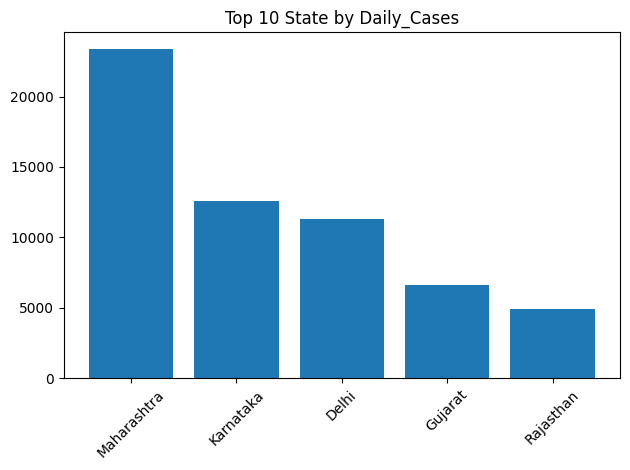

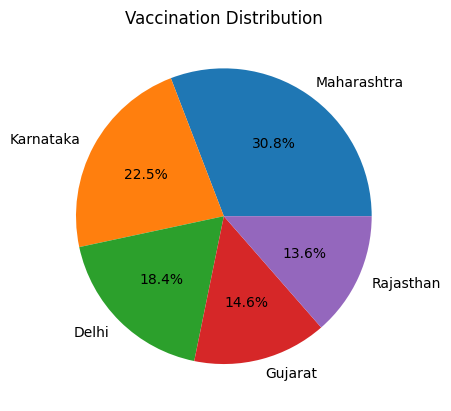

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("covid-19.csv")   # Change path if needed
print("Dataset Loaded Successfully")

# Show first rows
print(df.head())

# Basic info
print(df.info())
print(df.describe())

# Drop duplicate rows
df = df.drop_duplicates()

# Convert date column if available
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')


numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric Columns:", numeric_cols)


key_col = numeric_cols[0]
print("\nKey Column Selected for Statistics:", key_col)

mean_val = np.mean(df[key_col])
median_val = np.median(df[key_col])
mode_val = df[key_col].mode()[0]

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)


if 'date' in df.columns:
    df_sorted = df.sort_values(by="date")

    plt.figure()
    plt.plot(df_sorted['date'], df_sorted[key_col])
    plt.title(f"COVID {key_col} Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel(key_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


cat_col = None
for col in df.columns:
    if any(x in col.lower() for x in ['state','country','region']):
        cat_col = col
        break

if cat_col:
    top10 = df.groupby(cat_col)[key_col].sum().sort_values(ascending=False).head(10)

    plt.figure()
    plt.bar(top10.index, top10.values)
    plt.title(f"Top 10 {cat_col} by {key_col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ======================
# Pie Chart: Vaccination Distribution
# ======================
vacc_col = None
for col in df.columns:
    if 'vacc' in col.lower():
        vacc_col = col
        break

if vacc_col and cat_col:
    vacc_group = df.groupby(cat_col)[vacc_col].sum().sort_values(ascending=False).head(5)

    plt.figure()
    plt.pie(vacc_group.values, labels=vacc_group.index, autopct="%1.1f%%")
    plt.title("Vaccination Distribution")
    plt.show()
